## **Coin Counter and Calculator Project - YOLOv8**

> ##### Import library
| name              | description       |
|-------------------|-------------------|
| **YOLO**              | model             |
| **PIL**               | display image in system viewer    |
| **IPython.display**   | display image in notebook    |

In [1]:
from ultralytics import YOLO
from PIL import Image as PILImage
from IPython.display import Image as IPyImage

import os
import numpy as np
import cv2
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt


> ##### **for first train**
**Load a pretrained YOLOv8 small model**

In [9]:
model = YOLO("yolov8s.pt")

In [10]:
print(model)

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(96, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_s

**Start Training**

| parameter              | description       |
|-------------------|-------------------|
| **data**              | path to dataset config             |
| **epochs**               | number of epoch    |
| **imgsz**   | img size that yolo resize before passing into model    |
| **plots**   | save results like graph|
| **workers**   | subprocess|
| **resume**   | in case the model didnt finish training all epochs|

In [11]:
model.train(
    data="dataset/data.yaml", 
    epochs=20,
    imgsz=640,
    batch=16,
    plots=True,
    resume=False,
    workers=0
)

New https://pypi.org/project/ultralytics/8.3.203 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.202  Python-3.12.1 torch-2.8.0+cu129 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False

Exception ignored in: 'zmq.backend.cython._zmq.Frame.__dealloc__'
Traceback (most recent call last):
  File "zmq/backend/cython/_zmq.py", line 176, in zmq.backend.cython._zmq._check_rc
    PyErr_CheckSignals()
^^^^^^^^^^^
KeyboardInterrupt: 


RuntimeError: Dataset 'dataset/data.yaml' error  'dataset/data.yaml' does not exist

> ##### **To train further**
**Load best model to train further**

In [ ]:
# Load checkpoint (best or last)
model = YOLO("runs/detect/train/weights/best.pt")

model.train(
    data="dataset/data.yaml",
    epochs=20,
    imgsz=640,
    batch=16,
    plots=True,
    resume=False,
    workers=0
)

> ##### **Validation**

**Load best model to validate**

In [ ]:
model = YOLO("runs/detect/train/weights/best.pt")

**Validate**

In [ ]:
metrics = model.val(data="../dataset/data.yaml")

Ultralytics 8.3.202  Python-3.12.1 torch-2.8.0+cu129 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
Model summary (fused): 72 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 39.99.3 MB/s, size: 393.4 KB)
val: Scanning C:\Users\Jin\Documents\Work\2025-1\Digital-Image-Processing\Coin-Counter-Project\dataset\valid\labels.cache... 234 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 234/234 233.7Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 1.6it/s 9.6s0.2s
                   all        234        494       0.99      0.993      0.994      0.958
                     1         87        161      0.994      0.981      0.994      0.955
                    10         80        138      0.997          1      0.995      0.956
                     2         49         60      0.982          1      0.995      0.955
                     5         82        1

> ##### **Test Prediction**

In [ ]:
preds = model("../test_images/two_five_ten.jpg")
preds[0].show()


image 1/1 c:\Users\Jin\Documents\Work\2025-1\Digital-Image-Processing\Coin-Counter-Project\YOLOv8\..\test_images\two_five_ten.jpg: 640x640 1 10, 1 2, 1 5, 105.4ms
Speed: 6.9ms preprocess, 105.4ms inference, 7.8ms postprocess per image at shape (1, 3, 640, 640)


>##### **Performance Analysis**

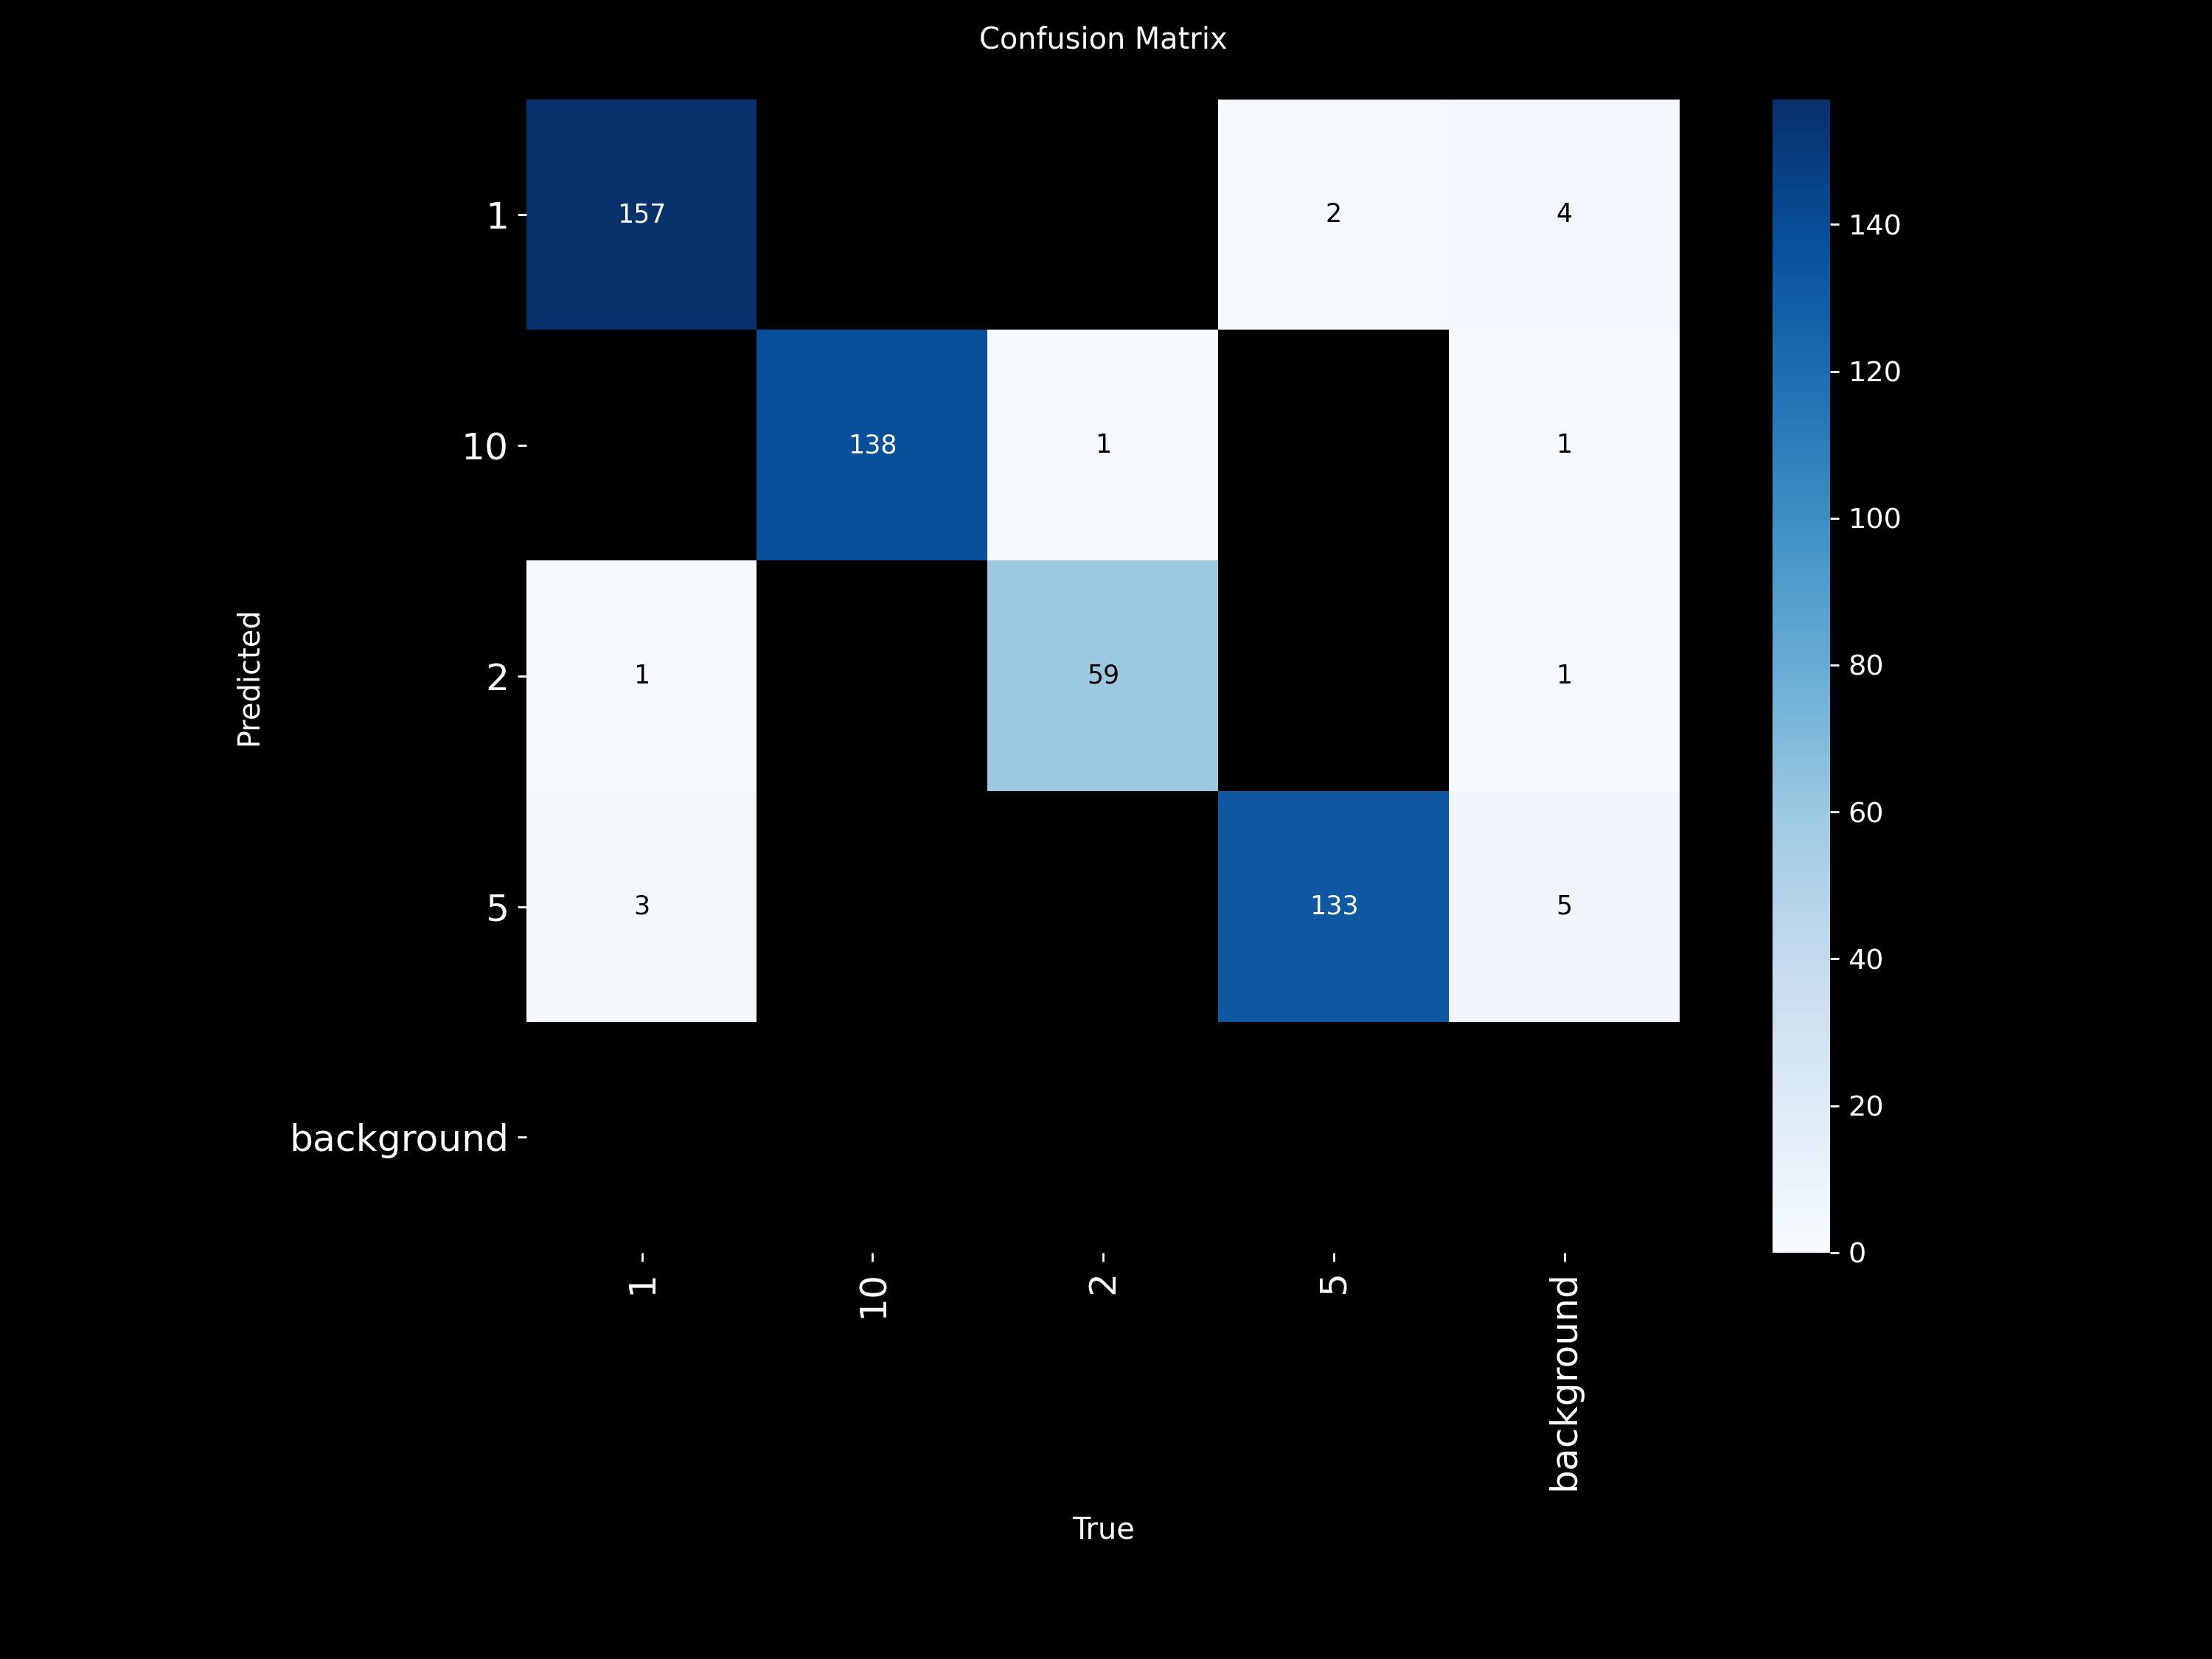

In [ ]:
display(IPyImage(filename='runs/detect/train/confusion_matrix.png', width=800))

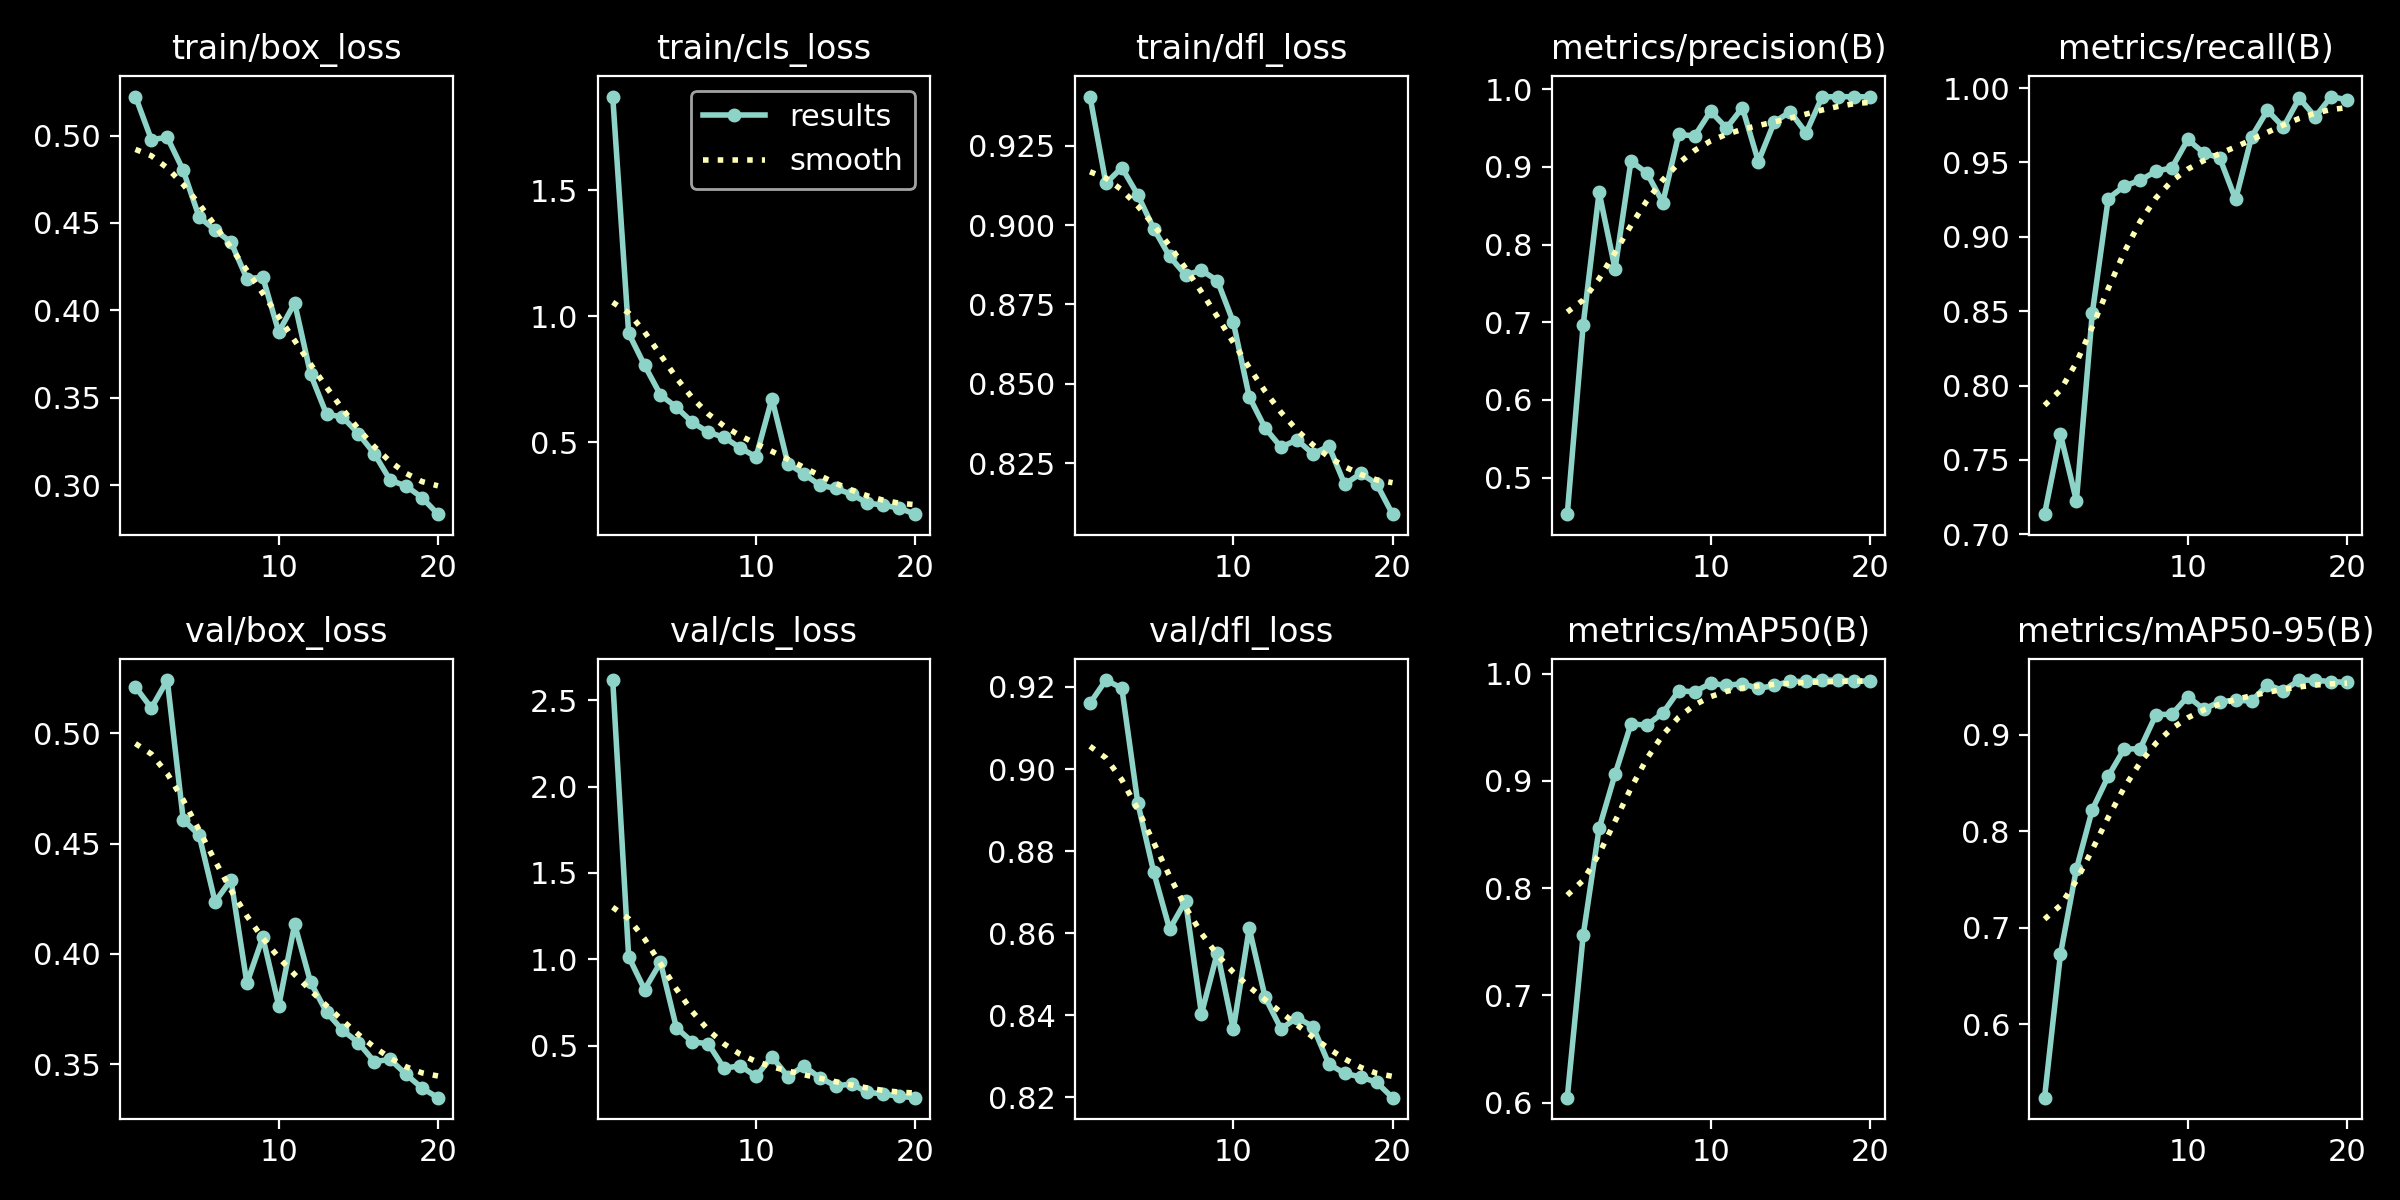

In [ ]:
display(IPyImage(filename=f'runs/detect/train/results.png', width=1000))
# img = PILImage.open("runs/detect/train/results.png")
# img.show()

In [ ]:
display(IPyImage(filename=f'runs/detect/train/val_batch0_pred.jpg', width=800))

img = PILImage.open("runs/detect/train/val_batch0_pred.jpg")
img.show()

> ##### **Visualize Backpropagation Gradient**
**Load trained model**

In [2]:
model = YOLO("runs/detect/train/weights/best.pt")
model.model.eval()

DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C2f(
      (cv1): Conv(
        (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(96, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
    

In [3]:
def preprocess_image(img_path, img_size=640):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (640, 640))

    # Prepare tensor
    img = torch.from_numpy(img).permute(2,0,1).float() / 255.0  # HWC -> CHW
    img = img.unsqueeze(0).to(next(model.model.parameters()).device)  # [1,C,H,W]
    
    return img

**Hook for Grad-CAM**

capture the output and gradients of the last convolutional layer.

In [5]:
activations = {}
gradients = {}

# Pick the last conv layer of YOLOv8 backbone (before Detect)
target_layer = model.model.model[21].cv1 # adjust if needed

target_layer._forward_hooks.clear()
target_layer._backward_hooks.clear()

print(target_layer)


def forward_hook(module, input, output):
    activations['value'] = output

def backward_hook(module, grad_in, grad_out):
    gradients['value'] = grad_out[0]
    
fwd_handle = target_layer.register_forward_hook(forward_hook)
bwd_handle = target_layer.register_backward_hook(backward_hook)


# Register hooks
# target_layer.register_forward_hook(forward_hook)
# target_layer.register_backward_hook(backward_hook)

Conv(
  (conv): Conv2d(768, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn): BatchNorm2d(512, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
  (act): SiLU(inplace=True)
)


In [19]:
def show_gradcam(img_path):
    
    # Load image
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (640, 640))

    # Prepare tensor
    img_tensor = torch.from_numpy(img_resized).permute(2,0,1).float() / 255.0  # HWC -> CHW
    img_tensor = img_tensor.unsqueeze(0).to(next(model.model.parameters()).device)
    img_tensor.requires_grad_(True)

    # Forward pass through backbone to trigger hooks
    outputs = model.model(img_tensor)

    # Use objectness of the highest-scoring predicted box
    pred_tensor = outputs[0]  # [1, num_boxes, 85]
    print(f"pred_tensor: {pred_tensor}")
    
    obj_scores = pred_tensor[0,:,4]
    print(f"obj_scores: {obj_scores}")
    
    top_idx = obj_scores.argmax()
    print(f"top_idx: {top_idx}")
    
    pred_class = pred_tensor[0, top_idx, 5:].argmax()
    score_tensor = pred_tensor[0, top_idx, 5 + pred_class]
    
    # score_tensor = obj_scores[top_idx]
    print(f"score_tensor: {score_tensor}")

    # Backward pass to get gradients
    model.model.zero_grad()
    score_tensor.backward()    
    
    print("Activation:", activations['value'].shape)
    print("Gradient:", gradients['value'].shape)

    # Grad-CAM computation
    grad = gradients['value'][0]  # [C,H,W]

    act = activations['value'][0] # [C,H,W]
    
    print("Grad min/max:", grad.min().item(), grad.max().item())

    
    weights = grad.mean(dim=(1,2), keepdim=True)  # global average pooling
    print(weights)
    
    cam = (weights * act).sum(dim=0)  # sum over channels
    
    cam = torch.relu(cam)
    cam = cam / (cam.max() + 1e-8)

    cam_np = cam.detach().cpu().numpy()
    cam_np = cv2.resize(cam_np, (img.shape[1], img.shape[0]))

    heatmap = cv2.applyColorMap(np.uint8(255*cam_np), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(img, 0.5, heatmap, 0.5, 0)
    
    cv2.imwrite('heatmap/correct_image.jpg', overlay)

    plt.figure(figsize=(8,8))
    plt.title(img_path)
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

**Accurate image**

pred_tensor: tensor([[[7.8605e+00, 1.3027e+01, 2.4637e+01,  ..., 5.3901e+02, 5.9838e+02, 6.0449e+02],
         [1.2400e+01, 6.7941e+00, 1.3100e+01,  ..., 6.0521e+02, 5.9905e+02, 5.9472e+02],
         [2.1075e+01, 2.5114e+01, 4.1053e+01,  ..., 2.0553e+02, 1.0272e+02, 1.1671e+02],
         ...,
         [1.5543e-07, 9.9831e-08, 4.3777e-07,  ..., 4.1124e-05, 1.3481e-05, 1.9989e-05],
         [5.4256e-07, 1.9377e-07, 8.6577e-07,  ..., 3.0620e-05, 1.3848e-05, 1.6942e-05],
         [2.0353e-08, 1.2607e-08, 5.2608e-08,  ..., 1.7388e-05, 4.0525e-06, 7.0298e-06]]], grad_fn=<CatBackward0>)
obj_scores: tensor([4.0121e+01, 1.1244e+01, 4.8652e+01, 2.3763e+01, 2.4292e-07, 4.3089e-07, 6.7639e-07, 5.3401e-08], grad_fn=<SelectBackward0>)
top_idx: 2
score_tensor: 601.7025146484375
Activation: torch.Size([1, 512, 20, 20])
Gradient: torch.Size([1, 512, 20, 20])
Grad min/max: 0.0 0.0
tensor([[[0.]],

        [[0.]],

        [[0.]],

        [[0.]],

        [[0.]],

        [[0.]],

        [[0.]],

     

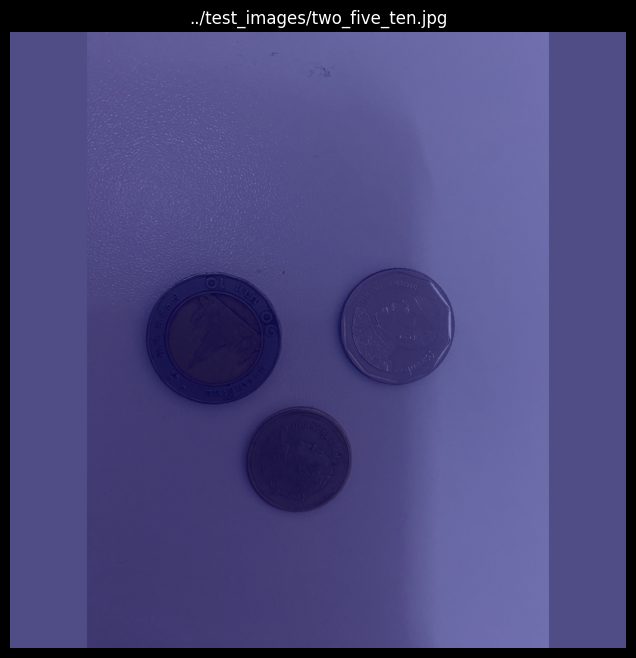

In [21]:
show_gradcam('../test_images/two_five_ten.jpg')


fwd_handle.remove()
bwd_handle.remove()


> ##### **In case model didn't finish training (error etc.)**
**Load last model to continue training**

In [ ]:
# Load checkpoint (last)
model = YOLO("runs/detect/train/weights/last.pt")

model.train(
    data="dataset/data.yaml",
    epochs=20,
    imgsz=640,
    batch=16,
    plots=True,
    resume=True,
    workers=0
)